**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.


# 05. Adaptive MCMC Samplers
This notebook covers adaptive Markov Chain Monte Carlo  sampler methods. The key idea behind adaptive MCMC is to learn the proposal covariance from the chain's own history, eliminating the need for manual tuning [[1]](#1).


## What You'll Learn
- Why adaptive MCMC improves mixing without manual tuning
- How ARWMH updates proposal covariance during warmup
- How DEMCz/DEMCzs use population proposals for complex posteriors
- How HMC and NUTS use gradients for efficient exploration
- How to compare adaptive samplers using acceptance rate and ESS

**Note:** Many code blocks in this notebook have longer run times due to the computationally expensive methods we are testing. Please allow up to 5 minutes of runtime per block before becoming concerned.

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy import stats
import pymc as pm

# Load Numerics DLL (auto-discovered from NuGet; see notebook 00 for details)
from helper_functions import resolve_numerics_dll
clr.AddReference(str(resolve_numerics_dll()))

# Import MCMC classes
from Numerics.Distributions import Normal, Uniform, Weibull, Logistic, Gumbel, IUnivariateDistribution
from Numerics.Sampling.MCMC import LogLikelihood, ARWMH, DEMCz, DEMCzs, HMC, NUTS, MCMCResults, MCMCDiagnostics
from helper_functions import convert_to_dotnet_array, create_comparison_table
from System.Collections.Generic import List
from System import Array, Double

print("✓ Setup complete")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ Setup complete


> **Note for demo users.** When calling Numerics MCMC samplers from Python via pythonnet, the samplers' internal parallel chains (`Parallel.For`) contend for Python's Global Interpreter Lock (GIL). This makes parallel execution slower than sequential. That's why every example below sets `sampler.ParallelizeChains = False`. It defaults to `True`, which works well in C# but slows the sampler down when driven from Python.

## Helper Functions
The basics of these functions are covered in previous notebooks. We define these here as helper functions to use in the rest of the notebook for efficiency.

In [2]:
def extract_chain_samples(results, param_indx):
    """Extract parameter samples from MCMC sampler results."""
    chains = []
    for c in range(len(results.MarkovChains)):
        chain = []
        for i in range(len(results.MarkovChains[c])):
            chain.append(float(results.MarkovChains[c][i].Values[param_indx]))
        chains.append(chain)
    return chains

def plot_trace(samples, param_names, title="Trace Plots"):
    """Plot MCMC trace plots."""
    n_params = len(samples)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 3*n_params))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].plot(sample, linewidth=0.5, alpha=0.7)
        axes[i].set_ylabel(name, fontsize=11)
        axes[i].set_xlabel('Iteration', fontsize=11)
        axes[i].grid(True, alpha=0.3)

        # Add mean line
        axes[i].axhline(np.mean(sample), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(sample):.3f}')
        axes[i].legend(fontsize=9)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

def plot_posterior(samples, param_names, true_values=None, title="Posterior Distributions"):
    """Plot posterior distributions."""
    n_params = len(samples)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 4))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].hist(sample, bins=50, density=True, alpha=0.7,
                    color='steelblue')
        axes[i].set_xlabel(name, fontsize=12)
        axes[i].set_ylabel('Density', fontsize=12)
        axes[i].grid(True, alpha=0.3, axis='y')

        if true_values is not None:
            axes[i].axvline(true_values[i], color='red', linestyle='--',
                          linewidth=2, label=f'True: {true_values[i]:.3f}')
            axes[i].legend(fontsize=10)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Adaptive Random Walk Metropolis-Hastings (ARWMH)
We will focus first on the most basic adaptive sampler: Adaptive Random Walk Metropolis-Hastings (ARWMH) which automatically tunes the proposal distribution during warmup [[1]](#1).

### Mathematical Foundation
The proposal at iteration $t$ uses a mixture:

$$
\theta^* \sim \begin{cases} \mathcal{N}\!\left(\theta, \, \frac{0.1^2}{d} \, I_d\right) & \text{with probability } \beta \\ \mathcal{N}\!\left(\theta, \, \frac{2.38^2}{d} \, \hat{\Sigma}_t\right) & \text{with probability } 1-\beta \end{cases}
$$

where:

- $d$ is the number of parameters (`NumberOfParameters`)
- $\beta = 0.05$ by default (the `Beta` property)
- $\hat{\Sigma}_t$ is the empirical covariance matrix computed as a running covariance of accepted samples (and current states after warmup)
- $I_d$ is the $d$-dimensional identity matrix
- The scale factor $s = 2.38^2/d$ is the `Scale` property

The small identity component (used with probability $\beta$, and also for the first $100 \times d$ samples) ensures ergodicity -- even if the adaptive covariance estimate is poor, the chain can still reach any region of the parameter space.

The acceptance criterion is identical to RWMH -- since both proposal components are symmetric multivariate normals centered at $\theta$, the Hastings ratio simplifies to the posterior ratio.

When to use ARWMH:
- Medium-dimensional problems (2-20 parameters)
- When you don't want to manually tune proposals
- Correlated parameters
- Default choice for most applications

Advantages:
- No manual tuning required
- Adapts to parameter correlations
- Generally more efficient than fixed RWMH


Adaptive RWMH Results


,Metric,Value,True
0,μ,100.611,100
1,σ estimate,15.053,15
2,ESS (μ),13589.486,---
3,ESS (σ),12435.469,---


Acceptance rates by chain


,Chain,Acceptance Rate
0,0,0.373
1,1,0.371
2,2,0.370
3,3,0.370


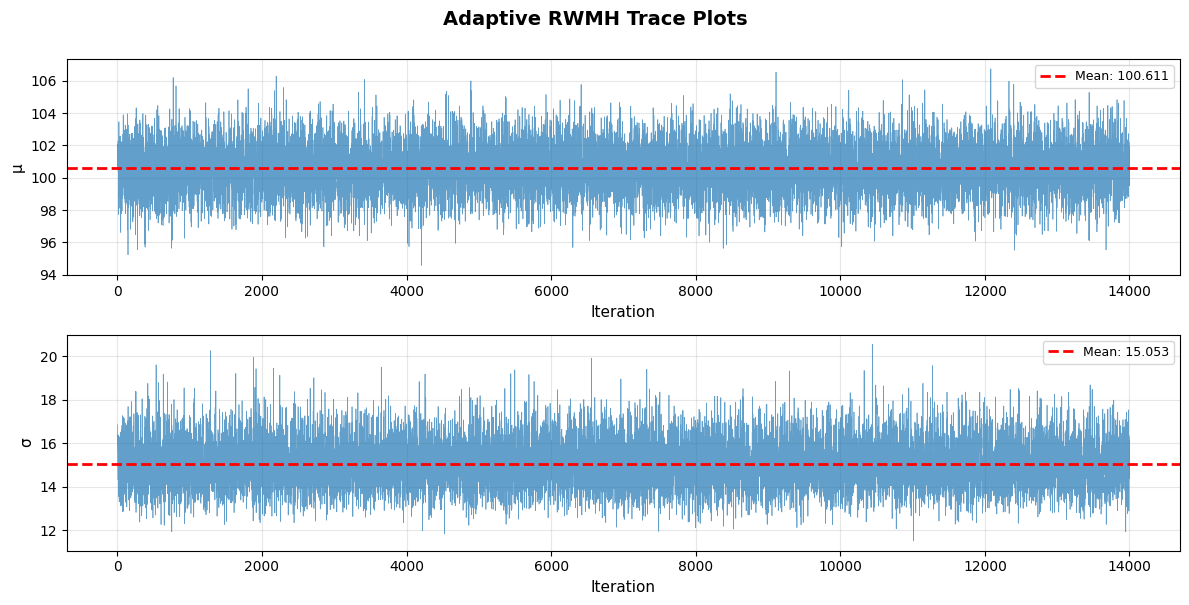

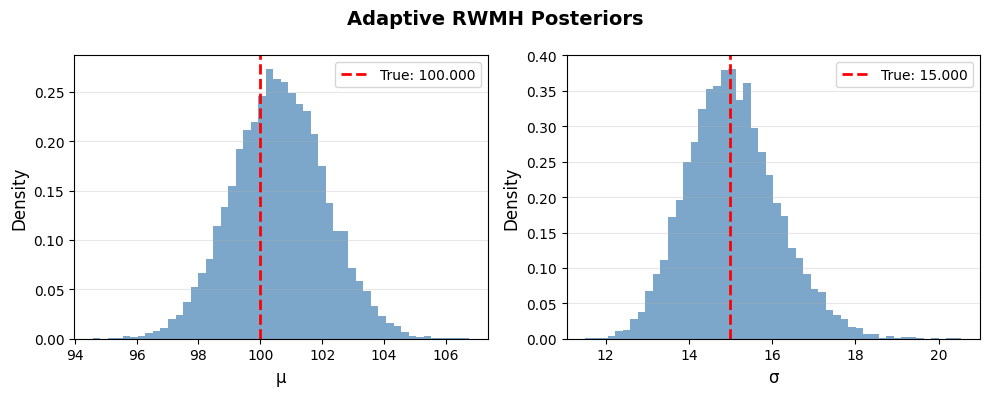

In [3]:
# Generate synthetic data
true_mu = 100
true_sigma = 15
data_net =  Normal(true_mu, true_sigma).GenerateRandomValues(100, 1234)
data = list(data_net)  # Convert to Python list for easier handling

# Define priors
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(50, 150))   # Prior for mu
priors.Add(Uniform(5, 30))     # Prior for sigma

# Log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], params[1])
    return sum(dist.LogPDF(x) for x in data)

# Convert to .NET Func
log_lik_func = LogLikelihood(log_likelihood)

# Create ARWMH sampler
arwmh = ARWMH(priors, log_lik_func)
arwmh.ParallelizeChains = False
arwmh.Sample()
arwmh_results = MCMCResults(arwmh)

mu_samples = extract_chain_samples(arwmh_results, 0)
sigma_samples = extract_chain_samples(arwmh_results, 1)
combined_mu = np.asarray(np.concatenate(mu_samples), dtype=float)
combined_sigma = np.asarray(np.concatenate(sigma_samples), dtype=float)

ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

arwmh_df = pd.DataFrame(
    {
        'Metric': ['μ', 'σ estimate', 'ESS (μ)', 'ESS (σ)'],
        'Value': [np.mean(combined_mu), np.mean(combined_sigma), ess_mu, ess_sigma],
        'True': [true_mu, true_sigma, "---", "---"],
    }
)
print("Adaptive RWMH Results")
display(arwmh_df.round(3))

acc_df = pd.DataFrame({'Chain': list(range(len(arwmh.AcceptanceRates))), 'Acceptance Rate': list(arwmh.AcceptanceRates)})
print("Acceptance rates by chain")
display(acc_df.round(3))

plot_trace([combined_mu, combined_sigma], ['μ', 'σ'], title="Adaptive RWMH Trace Plots")
plot_posterior([combined_mu, combined_sigma], ['μ', 'σ'], [true_mu, true_sigma], title="Adaptive RWMH Posteriors")


## Differential Evolution MCMC (DEMCz)
Differential Evolution MCMC (DEMCz) is a population-based sampler using differential evolution [[3]](#3). DEMCz with Snooker Update (DEMCzs) is an enhanced version with improved mixing.
### Mathematical Foundation 
DEMCz combines differential evolution (DE) with MCMC by using a population of chains and a history of past states to generate proposals. The mutation formula from the source code (`DEMCz.cs`) is:
$$
\theta^*_i = \theta_i + \gamma \, (z_{R_1} - z_{R_2}) + e
$$
where:
- $\gamma = 2.38 / \sqrt{2d}$ is the default jump rate (`Jump` property), with $d$ the number of parameters
- $z_{R_1}$ and $z_{R_2}$ are two randomly selected states from the population matrix (a memory of past states from all chains)
- $e \sim \mathcal{N}(0, b^2)$ is a small noise perturbation with default $b = 10^{-3}$ (`Noise` property)
- $R_1$ and $R_2$ are drawn uniformly without replacement from $\lbrace 1, 2, \ldots, M\rbrace$, where $M$ is the current size of the population matrix
The proposal is accepted using the standard Metropolis ratio in log space:
$$
\log \alpha = \log \pi(\theta^*) - \log \pi(\theta)
$$
To enable mode-jumping in multimodal posteriors, the jump rate $\gamma$ is set to $1.0$ with probability equal to `JumpThreshold` (default 0.1). When $\gamma = 1$, the proposal jumps the full difference between two past states, which can bridge gaps between separated modes.
The key insight of DEMCz is that the population matrix $Z$ serves as a memory of past states from **all** chains, providing a rich set of difference vectors for generating proposals. This eliminates the need for a manually specified proposal covariance matrix -- the population automatically learns the scale and orientation of the posterior.

When to use DEMCz:
- High-dimensional problems (20+ parameters)
- Multimodal posteriors
- Complex posterior geometry
- When ARWMH struggles with convergence
Advantages:
- Excellent for high dimensions
- Handles multimodal distributions
- Robust to initialization
- Self-tuning proposals from population

**DEMCzs is the fastest and most robust. It is the best adaptive method to default to.**


DEMCzs Results


,Metric,Value,True
0,μ,100.596,100
1,σ estimate,15.037,15
2,ESS (μ),13133.402,---
3,ESS (σ),13443.988,---


Acceptance rates by chain


,Chain,Acceptance Rate
0,0,0.345
1,1,0.344
2,2,0.346
3,3,0.341


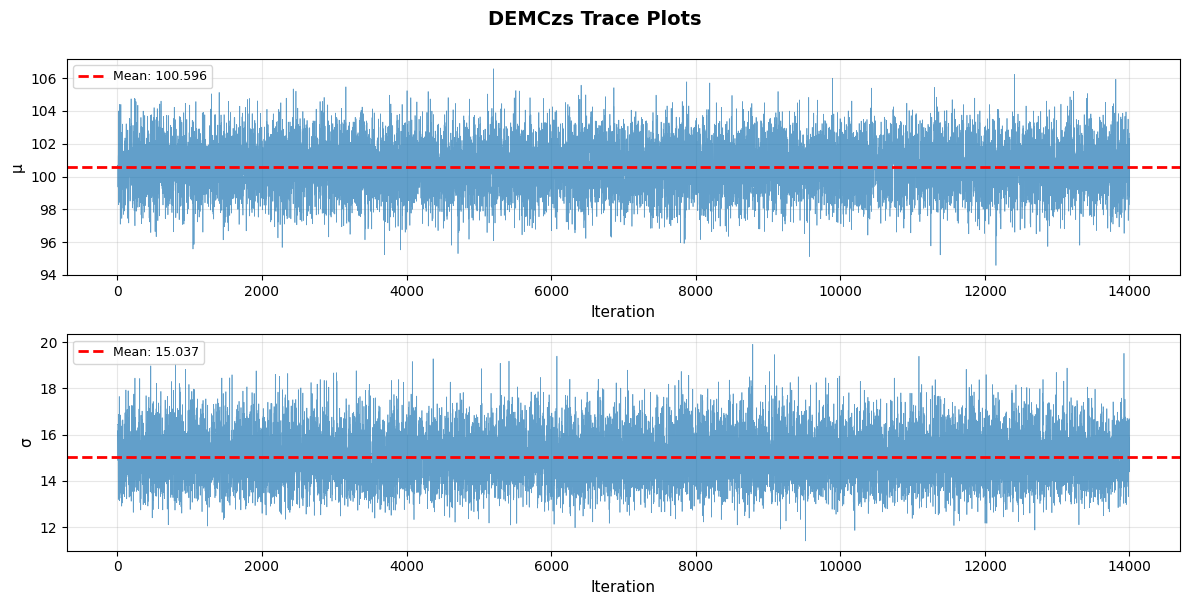

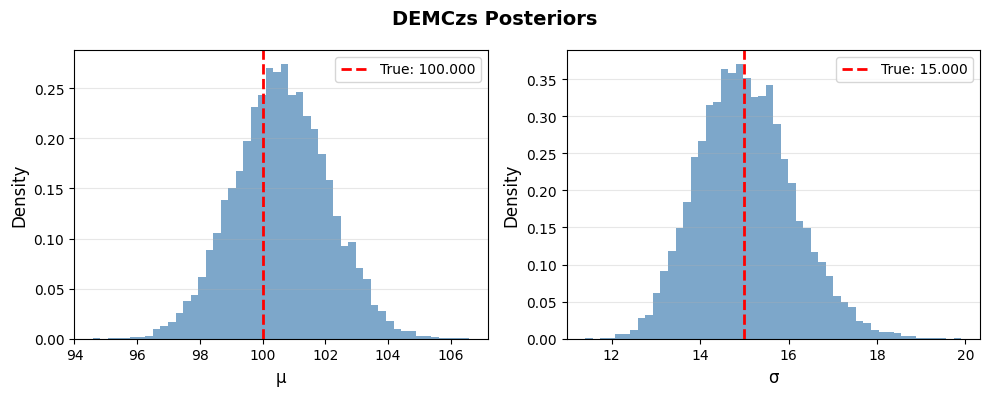

In [4]:
# Create ARWMH sampler
demczs = DEMCzs(priors, log_lik_func)
demczs.ParallelizeChains = False
demczs.Sample()
demczs_results = MCMCResults(demczs)

mu_samples = extract_chain_samples(demczs_results, 0)
sigma_samples = extract_chain_samples(demczs_results, 1)
combined_mu = np.asarray(np.concatenate(mu_samples), dtype=float)
combined_sigma = np.asarray(np.concatenate(sigma_samples), dtype=float)

ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

arwmh_df = pd.DataFrame(
    {
        'Metric': ['μ', 'σ estimate', 'ESS (μ)', 'ESS (σ)'],
        'Value': [np.mean(combined_mu), np.mean(combined_sigma), ess_mu, ess_sigma],
        'True': [true_mu, true_sigma, "---", "---"],
    }
)
print("DEMCzs Results")
display(arwmh_df.round(3))

acc_df = pd.DataFrame({'Chain': list(range(len(demczs.AcceptanceRates))), 'Acceptance Rate': list(demczs.AcceptanceRates)})
print("Acceptance rates by chain")
display(acc_df.round(3))

plot_trace([combined_mu, combined_sigma], ['μ', 'σ'], title="DEMCzs Trace Plots")
plot_posterior([combined_mu, combined_sigma], ['μ', 'σ'], [true_mu, true_sigma], title="DEMCzs Posteriors")


## Comparing MCMC Samplers

Different samplers have different strengths. We will compare all of our adaptive samplers:

- ARWMH: Adaptive Random Walk MH (auto-tuning)
- DEMCz: Differential Evolution MCMC (population-based)
- DEMCzs: DEMCz with snooker update (better for complex posteriors)
- HMC: Hamiltonian Monte Carlo (uses gradients)
- NUTS: No-U Turn Sampler (adaptive HMC)

Before we start, let's go through the our last two samplers.



### HMC Mathematical Foundation
Hamiltonian Monte Carlo (HMC) uses gradient information for efficient sampling [[4]](#4)[[5]](#5). HMC augments the parameter space with auxiliary momentum variables $\phi$ and simulates Hamiltonian dynamics to generate distant, high-quality proposals. The Hamiltonian is defined as:

$$
H(\theta, \phi) = U(\theta) + K(\phi) = -\log \pi(\theta) + \frac{1}{2} \phi^T M^{-1} \phi
$$

where $U(\theta) = -\log \pi(\theta)$ is the potential energy (negative log-posterior) and $K(\phi)$ is the kinetic energy. The mass matrix $M$ is diagonal in the Numerics implementation (the `Mass` vector property).

When to use HMC:
- Smooth, differentiable posteriors
- When gradient information is available
- Need for low autocorrelation
- Medium to high dimensions with smooth geometry

Advantages:
- Very efficient (low autocorrelation)
- Explores parameter space quickly
- Excellent for smooth posteriors

Disadvantages:
- Requires gradient computation
- Less robust to discontinuities
- More complex to tune

### NUTS Mathematical Foundation 
No-U-Turn Sampler (NUTS) automatically tunes the trajectory length that HMC requires as a manual setting, making it the recommended gradient-based sampler for most problems [[6]](#6). NUTS eliminates HMC's most sensitive tuning parameter -- the number of leapfrog steps $L$ -- by automatically determining when to stop the trajectory. It builds a balanced binary tree of leapfrog states using the following procedure:

1. Sample momentum $\phi \sim \mathcal{N}(0, M)$
2. Recursively double the trajectory in a randomly chosen direction (forward or backward)
3. Stop when a U-turn is detected or the maximum tree depth is reached

The U-turn criterion (from `NUTS.cs`) checks whether the trajectory endpoints are moving apart or starting to return:

$$
(\theta^+ - \theta^-) \cdot \phi^- < 0 \quad \text{or} \quad (\theta^+ - \theta^-) \cdot \phi^+ < 0
$$

where $\theta^+$ and $\theta^-$ are the forward and backward endpoints of the trajectory, and $\phi^+$ and $\phi^-$ are their corresponding momenta. When either dot product is negative, the trajectory has started to curve back on itself.

When to use NUTS:
- Smooth, differentiable posteriors (same as HMC)
- When you don't want to tune the number of leapfrog steps
- Default gradient-based sampler for most applications
- Medium to high dimensions

Advantages over HMC:
- No manual tuning of trajectory length
- Adapts step size automatically via dual averaging
- Eliminates wasteful U-turns in the trajectory
- Generally more efficient per computation


### Gumbel Example

Now that we have defined all of our samplers, we will fit a Gumbel distribution to synthetic data using all samplers. We are only comparing adaptive samplers with other adaptive samplers. As usual, we will draw random samples from the posterior and graph their posterior distributions.

The Gumbel is a good choice for this gradient-based comparison because its log-density is smooth and its gradient is cheap to evaluate numerically, so HMC and NUTS can do their work without the step-size thrashing that heavier-tailed distributions (e.g., Weibull) can induce during automatic differentiation.

In [5]:
# Generate Gumbel data
true_xi = 10.0       # location
true_alpha = 2.0     # scale
gumbel_data = list(Gumbel(true_xi, true_alpha).GenerateRandomValues(50, 12345))

priors_gumbel = List[IUnivariateDistribution]()
priors_gumbel.Add(Uniform(0.0, 20.0))   # xi
priors_gumbel.Add(Uniform(0.5, 10.0))   # alpha


def log_lik_gumbel(params):
    # Guard invalid probes from numerical differentiation.
    xi = float(params[0])
    alpha = float(params[1])
    if alpha <= 0.0:
        return float("-inf")
    dist = Gumbel(xi, alpha)
    return sum(dist.LogPDF(x) for x in gumbel_data)


log_lik_gumbel_func = LogLikelihood(log_lik_gumbel)

samplers_to_test = {
    "ARWMH": lambda: ARWMH(priors_gumbel, log_lik_gumbel_func),
    "DEMCz": lambda: DEMCz(priors_gumbel, log_lik_gumbel_func),
    "DEMCzs": lambda: DEMCzs(priors_gumbel, log_lik_gumbel_func),
    "HMC": lambda: HMC(priors_gumbel, log_lik_gumbel_func, stepSize=0.03, steps=3),
    "NUTS": lambda: NUTS(priors_gumbel, log_lik_gumbel_func, stepSize=0.1, maxTreeDepth=7),
}

# Per-sampler runtime budgets (NUTS and HMC get fewer iterations because each iteration is costlier).
# DEMCz and DEMCzs require at least 3 chains to run
settings = {
    "ARWMH": dict(warmup=800, iters=2500, out=2500, thin=1, chains=1),
    "DEMCz": dict(warmup=800, iters=2500, out=2500, thin=1, chains=3),
    "DEMCzs": dict(warmup=800, iters=2500, out=2500, thin=1, chains=3),
    "HMC": dict(warmup=600, iters=2000, out=2000, thin=1, chains=1),
    "NUTS": dict(warmup=400, iters=1200, out=1200, thin=1, chains=1),
}

out_results = {}
summary_rows = []
print("Comparing MCMC samplers...")

for name, create_sampler in samplers_to_test.items():
    print(f"Running {name}...")
    sampler = create_sampler()

    cfg = settings[name]
    sampler.WarmupIterations = cfg["warmup"]
    sampler.Iterations = cfg["iters"]
    sampler.OutputLength = cfg["out"]
    sampler.ThinningInterval = cfg["thin"]

    sampler.NumberOfChains = cfg["chains"]
    sampler.ParallelizeChains = False

    start = time.time()
    sampler.Sample()
    elapsed = time.time() - start

    results = MCMCResults(sampler)
    chains_xi = extract_chain_samples(results, 0)
    chains_alpha = extract_chain_samples(results, 1)

    combined_xi = np.asarray(np.concatenate(chains_xi), dtype=float)
    combined_alpha = np.asarray(np.concatenate(chains_alpha), dtype=float)

    est_xi = np.mean(combined_xi)
    est_alpha = np.mean(combined_alpha)
    ess_xi = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_xi))) if combined_xi.size > 0 else 0.0
    ess_alpha = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_alpha))) if combined_alpha.size > 0 else 0.0

    out_results[name] = {
        "xi": combined_xi,
        "alpha": combined_alpha,
        "time": elapsed,
        "ess_xi": ess_xi,
        "ess_alpha": ess_alpha,
    }

    summary_rows.append(
        {
            "Sampler": name,
            "Runtime (s)": elapsed,
            "ξ Estimate": est_xi,
            "α Estimate": est_alpha,
            "ξ Error": est_xi - true_xi,
            "α Error": est_alpha - true_alpha,
            "ESS (ξ)": ess_xi,
            "ESS (α)": ess_alpha,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("Runtime (s)")
print("Sampler comparison summary")
display(summary_df.round(3))


Comparing MCMC samplers...
Running ARWMH...


Running DEMCz...


Running DEMCzs...


Running HMC...


Running NUTS...


Sampler comparison summary


,Sampler,Runtime (s),ξ Estimate,α Estimate,ξ Error,α Error,ESS (ξ),ESS (α)
0,ARWMH,0.452,10.422,2.342,0.422,0.342,295.435,240.313
1,DEMCz,0.788,10.395,2.349,0.395,0.349,604.417,373.917
2,DEMCzs,0.797,10.375,2.335,0.375,0.335,578.612,801.738
3,HMC,7.339,10.379,2.358,0.379,0.358,72.223,102.306
4,NUTS,7.853,10.418,2.356,0.418,0.356,321.281,389.611


## Performance Benchmark: Numerics vs PyMC
Now let's compare Numerics DEMCzs vs Numerics NUTS vc Python's PyMC NUTS [[6]](#6). All are adaptive samplers, so this is an apples-to-apples comparison. We look to compare run times and accuracy.

**Note:** This requires PyMC to be installed:
```bash
pip install pymc arviz
```
In the benchmark below, both Numerics methods often runs faster than PyMC. Your results may vary by machine, sampler settings, and version.

**Note:** Numerics applies thinning by default, so its MarkovChains are already thinned. When comparing to PyMC, match PyMC draws to the Numerics chain length or set Numerics ThinningInterval to 1. Also check other default parameters to truly get a fair comparison.



Running DEMCzs...


Numerics DEMCzs Performance:
  Runtime: 0.228 seconds
  Mean μ:  12684.81
  Mean σ:  4815.46

Running Numerics NUTS...


Numerics NUTS Performance:
  Runtime: 6.118 seconds
  Mean μ:  12658.13
  Mean σ:  4833.98

Running PyMC...


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [mu, sigma]


Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 30 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


Numerics PyMC Performance:
  Runtime: 32.544 seconds
  Mean μ:  12641.05
  Mean σ:  4826.64

PERFORMANCE COMPARISON: Numerics DEMCzs vs Numerics NUTS vs PyMC
Numerics DEMCzs:  0.228 seconds
Numerics NUTS:    6.118 seconds
PyMC (NUTS):      32.544 seconds

 Numerics Speedup vs PyMC:
  DEMCzs: 142.74x faster
  NUTS:   5.32x faster


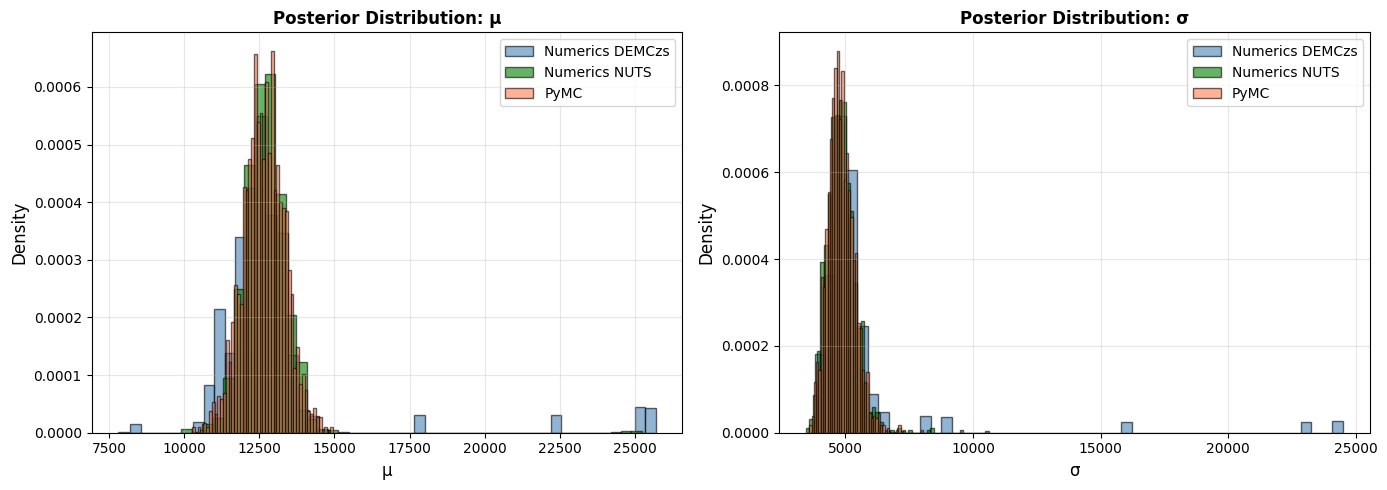

In [6]:
try:    
    flood_data = Array[Double]([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000, 
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600, 
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600, 
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600, 
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460])

    # Shared PyMC data
    pymc_data = np.array(list(flood_data))

    normal = Normal()
    constraints = normal.GetParameterConstraints(flood_data)
    mu_prior = Uniform(constraints.Item2[0], constraints.Item3[0])
    sigma_prior = Uniform(constraints.Item2[1], constraints.Item3[1])
    priors = List[IUnivariateDistribution]()
    priors.Add(mu_prior)
    priors.Add(sigma_prior)

    def log_likelihood(params):
        dist = Normal(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    log_lik_func = LogLikelihood(log_likelihood)


    # Numerics
    print("\nRunning DEMCzs...")
    start_demczs = time.perf_counter()
    sampler_demczs = DEMCzs(priors, log_lik_func)
    sampler_demczs.ParallelizeChains = False
    sampler_demczs.ThinningInterval = 1
    sampler_demczs.WarmupIterations = 1000
    sampler_demczs.Iterations = 2000
    sampler_demczs.NumberOfChains = 3
    sampler_demczs.Sample()
    time_demczs = time.perf_counter() - start_demczs
    results_demczs = MCMCResults(sampler_demczs)

    demczs_mean_mu = results_demczs.ParameterResults[0].SummaryStatistics.Mean
    demczs_mean_sigma = results_demczs.ParameterResults[1].SummaryStatistics.Mean

    print("Numerics DEMCzs Performance:")
    print(f"  Runtime: {time_demczs:.3f} seconds")
    print(f"  Mean μ:  {demczs_mean_mu:.2f}")
    print(f"  Mean σ:  {demczs_mean_sigma:.2f}")

    # Numerics NUTS
    print("\nRunning Numerics NUTS...")
    nuts_start = time.perf_counter()
    sampler_nuts = NUTS(priors, log_lik_func)
    sampler_nuts.ParallelizeChains = False
    sampler_nuts.ThinningInterval = 1
    sampler_nuts.WarmupIterations = 1000
    sampler_nuts.Iterations = 2000
    sampler_nuts.NumberOfChains = 1
    sampler_nuts.Sample()
    time_nuts = time.perf_counter() - nuts_start
    results_nuts = MCMCResults(sampler_nuts)
    
    nuts_mean_mu = results_nuts.ParameterResults[0].SummaryStatistics.Mean
    nuts_mean_sigma = results_nuts.ParameterResults[1].SummaryStatistics.Mean
    
    print("Numerics NUTS Performance:")
    print(f"  Runtime: {time_nuts:.3f} seconds")
    print(f"  Mean μ:  {nuts_mean_mu:.2f}")
    print(f"  Mean σ:  {nuts_mean_sigma:.2f}")
    
    # PyMC NUTs
    print("\nRunning PyMC...")
    pymc_start = time.perf_counter()
    
    pymc_data = np.array(list(flood_data))
    
    with pm.Model() as model:
        # Priors
        mu = pm.Uniform('mu', lower=constraints.Item2[0], upper=constraints.Item3[0])
        sigma = pm.Uniform('sigma', lower=constraints.Item2[1], upper=constraints.Item3[1])
        
        # Likelihood
        y = pm.Normal('y', mu=mu, sigma=sigma, observed=pymc_data)
        
        # Added: Numerics returns thinned samples by default, so match PyMC draws to Numerics chain length
        target_draws = len(results_demczs.MarkovChains[0])
        target_tune = sampler_demczs.WarmupIterations
        # Sample - tuned to match Numerics settings
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=1, progressbar=False, random_seed=12345)
    
    pymc_time = time.perf_counter() - pymc_start
    
    # Extract PyMC results
    mu_samples_pymc = trace.posterior['mu'].values.flatten()
    sigma_samples_pymc = trace.posterior['sigma'].values.flatten()
    
    print("Numerics PyMC Performance:")
    print(f"  Runtime: {pymc_time:.3f} seconds")
    print(f"  Mean μ:  {np.mean(mu_samples_pymc):.2f}")
    print(f"  Mean σ:  {np.mean(sigma_samples_pymc):.2f}")
    
        # Performance comparison
    print("\nPERFORMANCE COMPARISON: Numerics DEMCzs vs Numerics NUTS vs PyMC")
    print(f"Numerics DEMCzs:  {time_demczs:.3f} seconds")
    print(f"Numerics NUTS:    {time_nuts:.3f} seconds")
    print(f"PyMC (NUTS):      {pymc_time:.3f} seconds")
    print(f"\n Numerics Speedup vs PyMC:")
    print(f"  DEMCzs: {pymc_time/time_demczs:.2f}x faster")
    print(f"  NUTS:   {pymc_time/time_nuts:.2f}x faster")
    
    # Update visual comparison to include NUTS
    demczs_mu_extract = [results_demczs.MarkovChains[0][i].Values[0] for i in range(len(results_demczs.MarkovChains[0]))]
    nuts_mu_extract = [results_nuts.MarkovChains[0][i].Values[0] for i in range(len(results_nuts.MarkovChains[0]))]
    
    demczs_sigma_extract = [results_demczs.MarkovChains[0][i].Values[1] for i in range(len(results_demczs.MarkovChains[0]))]
    nuts_sigma_extract = [results_nuts.MarkovChains[0][i].Values[1] for i in range(len(results_nuts.MarkovChains[0]))]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(demczs_mu_extract, bins=50, density=True, alpha=0.6, color='steelblue', label='Numerics DEMCzs', edgecolor='black')
    axes[0].hist(nuts_mu_extract, bins=50, density=True, alpha=0.6, color='green', label='Numerics NUTS', edgecolor='black')
    axes[0].hist(mu_samples_pymc, bins=50, density=True, alpha=0.6, color='coral', label='PyMC', edgecolor='black')
    axes[0].set_xlabel('μ', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].set_title('Posterior Distribution: μ', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(demczs_sigma_extract, bins=50, density=True, alpha=0.6, color='steelblue', label='Numerics DEMCzs', edgecolor='black')
    axes[1].hist(nuts_sigma_extract, bins=50, density=True, alpha=0.6, color='green', label='Numerics NUTS', edgecolor='black')
    axes[1].hist(sigma_samples_pymc, bins=50, density=True, alpha=0.6, color='coral', label='PyMC', edgecolor='black')
    axes[1].set_xlabel('σ', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Posterior Distribution: σ', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")

### More PyMC Comparison Tests
Above we tested Numerics against PyMC for a Normal distribution. Below are more comparison tests for the various distributions in Numerics. Since MCMC methods rely on random number generation, Numerics results will not be exactly the same as those produced by PyMC. Therefore, these comparisons aim to verify whether the results are within 5% of each other.


In [7]:
try:
    flood_data = Array[Double]([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000, 
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600, 
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600, 
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600, 
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460])

    # Shared PyMC data
    pymc_data = np.array(list(flood_data))

    # Logistic distribution Comparison
    print("Logistic Distribution [PyMC Comparison]")

    log = Logistic()
    constraints_log = log.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
    alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])
    priors_logistic = List[IUnivariateDistribution]()
    priors_logistic.Add(xi_prior)
    priors_logistic.Add(alpha_prior)

    def log_likelihood_logistic(params):
        dist = Logistic(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    log_lik_func = LogLikelihood(log_likelihood_logistic)

    log_numerics_start = time.perf_counter()
    sampler_logistic = DEMCzs(priors_logistic, log_lik_func)
    sampler_logistic.ParallelizeChains = False
    sampler_logistic.Sample()
    results_logistic = MCMCResults(sampler_logistic)
    log_numerics_time = time.perf_counter() - log_numerics_start

    log_pymc_start = time.perf_counter()

    with pm.Model() as model:
        xi = pm.Uniform('xi', lower=constraints_log.Item2[0], upper=constraints_log.Item3[0])
        alpha = pm.Uniform('alpha', lower=constraints_log.Item2[1], upper=constraints_log.Item3[1])
        y = pm.Logistic('y', mu=xi, s=alpha, observed=pymc_data)
        target_draws = len(results_logistic.MarkovChains[0])
        target_tune = sampler_logistic.WarmupIterations
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=3, progressbar=False, random_seed=12345)

    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    log_pymc_time = time.perf_counter() - log_pymc_start

    numericsResults = [
        results_logistic.ParameterResults[0].SummaryStatistics.Mean,
        results_logistic.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_logistic.ParameterResults[0].SummaryStatistics.LowerCI,
        results_logistic.ParameterResults[0].SummaryStatistics.Median,
        results_logistic.ParameterResults[0].SummaryStatistics.UpperCI,
        results_logistic.ParameterResults[1].SummaryStatistics.Mean,
        results_logistic.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_logistic.ParameterResults[1].SummaryStatistics.LowerCI,
        results_logistic.ParameterResults[1].SummaryStatistics.Median,
        results_logistic.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples, 5), np.median(xiSamples), np.percentile(xiSamples, 95),
        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples, 5), np.median(alphaSamples), np.percentile(alphaSamples, 95)
    ]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI',
                      'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, log_numerics_time, log_pymc_time)
    display(comparison_df)
    print(f"Speedup: {log_pymc_time/log_numerics_time:.2f}x faster with Numerics\n")

    # Gumbel distribution Comparison
    print("Gumbel Distribution [PyMC Comparison]")

    gumbel = Gumbel()
    constraints_gumbel = gumbel.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_gumbel.Item2[0], constraints_gumbel.Item3[0])
    alpha_prior = Uniform(constraints_gumbel.Item2[1], constraints_gumbel.Item3[1])
    priors_gumbel = List[IUnivariateDistribution]()
    priors_gumbel.Add(xi_prior)
    priors_gumbel.Add(alpha_prior)

    def log_likelihood_gumbel(params):
        dist = Gumbel(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    gumbel_lik_func = LogLikelihood(log_likelihood_gumbel)

    gumbel_numerics_start = time.perf_counter()
    sampler_gumbel = DEMCzs(priors_gumbel, gumbel_lik_func)
    sampler_gumbel.ParallelizeChains = False
    sampler_gumbel.Sample()
    results_gumbel = MCMCResults(sampler_gumbel)
    gumbel_numerics_time = time.perf_counter() - gumbel_numerics_start

    gumbel_pymc_start = time.perf_counter()

    with pm.Model() as model:
        xi = pm.Uniform('xi', lower=constraints_gumbel.Item2[0], upper=constraints_gumbel.Item3[0])
        alpha = pm.Uniform('alpha', lower=constraints_gumbel.Item2[1], upper=constraints_gumbel.Item3[1])
        y = pm.Gumbel('y', mu=xi, beta=alpha, observed=pymc_data)
        # Added: Numerics returns thinned samples by default, so match PyMC draws to Numerics chain length
        target_draws = len(results_gumbel.MarkovChains[0])
        target_tune = sampler_gumbel.WarmupIterations
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=3, progressbar=False, random_seed=12345)

    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    gumbel_pymc_time = time.perf_counter() - gumbel_pymc_start

    numericsResults = [
        results_gumbel.ParameterResults[0].SummaryStatistics.Mean,
        results_gumbel.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_gumbel.ParameterResults[0].SummaryStatistics.LowerCI,
        results_gumbel.ParameterResults[0].SummaryStatistics.Median,
        results_gumbel.ParameterResults[0].SummaryStatistics.UpperCI,
        results_gumbel.ParameterResults[1].SummaryStatistics.Mean,
        results_gumbel.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_gumbel.ParameterResults[1].SummaryStatistics.LowerCI,
        results_gumbel.ParameterResults[1].SummaryStatistics.Median,
        results_gumbel.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples, 5), np.median(xiSamples), np.percentile(xiSamples, 95),
        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples, 5), np.median(alphaSamples), np.percentile(alphaSamples, 95)
    ]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI',
                      'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, gumbel_numerics_time, gumbel_pymc_time)
    display(comparison_df)
    print(f"Speedup: {gumbel_pymc_time/gumbel_numerics_time:.2f}x faster with Numerics\n")

    # Weibull distribution Comparison
    print("Weibull Distribution [PyMC Comparison]")

    weibull = Weibull()
    constraints_weibull = weibull.GetParameterConstraints(flood_data)
    lambda_prior = Uniform(constraints_weibull.Item2[0], constraints_weibull.Item3[0])
    kappa_prior = Uniform(constraints_weibull.Item2[1], constraints_weibull.Item3[1])
    priors_weibull = List[IUnivariateDistribution]()
    priors_weibull.Add(lambda_prior)
    priors_weibull.Add(kappa_prior)

    def log_likelihood_weibull(params):
        dist = Weibull(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    weibull_lik_func = LogLikelihood(log_likelihood_weibull)

    weibull_numerics_start = time.perf_counter()
    sampler_weibull = DEMCzs(priors_weibull, weibull_lik_func)
    sampler_weibull.ParallelizeChains = False
    sampler_weibull.Sample()
    results_weibull = MCMCResults(sampler_weibull)
    weibull_numerics_time = time.perf_counter() - weibull_numerics_start

    weibull_pymc_start = time.perf_counter()

    with pm.Model() as model:
        kappa = pm.Uniform('kappa', lower=constraints_weibull.Item2[1], upper=constraints_weibull.Item3[1])
        lambda_ = pm.Uniform('lambda', lower=constraints_weibull.Item2[0], upper=constraints_weibull.Item3[0])
        y = pm.Weibull('y', alpha=kappa, beta=lambda_, observed=pymc_data)
        # Added: Numerics returns thinned samples by default, so match PyMC draws to Numerics chain length
        target_draws = len(results_weibull.MarkovChains[0])
        target_tune = sampler_weibull.WarmupIterations
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=3, progressbar=False, random_seed=12345)

    kappaSamples = trace.posterior['kappa'].values.flatten()
    lambdaSamples = trace.posterior['lambda'].values.flatten()

    weibull_pymc_time = time.perf_counter() - weibull_pymc_start

    numericsResults = [
        results_weibull.ParameterResults[0].SummaryStatistics.Mean,
        results_weibull.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_weibull.ParameterResults[0].SummaryStatistics.LowerCI,
        results_weibull.ParameterResults[0].SummaryStatistics.Median,
        results_weibull.ParameterResults[0].SummaryStatistics.UpperCI,
        results_weibull.ParameterResults[1].SummaryStatistics.Mean,
        results_weibull.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_weibull.ParameterResults[1].SummaryStatistics.LowerCI,
        results_weibull.ParameterResults[1].SummaryStatistics.Median,
        results_weibull.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    # Numerics prior order was [lambda_prior, kappa_prior], so ParameterResults[0]=Lambda and [1]=Kappa.
    comparisonResults = [
        np.mean(lambdaSamples), np.std(lambdaSamples), np.percentile(lambdaSamples, 5), np.median(lambdaSamples), np.percentile(lambdaSamples, 95),
        np.mean(kappaSamples), np.std(kappaSamples), np.percentile(kappaSamples, 5), np.median(kappaSamples), np.percentile(kappaSamples, 95)
    ]

    parameterNames = ['Lambda Mean', 'Lambda StdDev', 'Lambda Lower CI', 'Lambda Median', 'Lambda Upper CI',
                      'Kappa Mean', 'Kappa StdDev', 'Kappa Lower CI', 'Kappa Median', 'Kappa Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, weibull_numerics_time, weibull_pymc_time)
    display(comparison_df)
    print(f"Speedup: {weibull_pymc_time/weibull_numerics_time:.2f}x faster with Numerics\n")

except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")


Logistic Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (3 chains in 3 jobs)


NUTS: [xi, alpha]


Sampling 3 chains for 1_750 tune and 3_500 draw iterations (5_250 + 10_500 draws total) took 85 seconds.


...

NUTS: [kappa, lambda]


Sampling 3 chains for 1_750 tune and 3_500 draw iterations (5_250 + 10_500 draws total) took 78 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


,Parameter,Numerics Result,PyMC Result,Difference
0,Lambda Mean,14279.649851,14289.042029,-0.0657%
1,Lambda StdDev,735.280566,737.035951,-0.2382%
2,Lambda Lower CI,13105.856123,13122.431346,-0.1263%
3,Lambda Median,14266.372154,14278.392251,-0.0842%
4,Lambda Upper CI,15514.592819,15514.805284,-0.0014%
5,Kappa Mean,2.978184,2.9862,-0.2684%
6,Kappa StdDev,0.337959,0.337868,0.0269%
7,Kappa Lower CI,2.439959,2.442829,-0.1175%
8,Kappa Median,2.964872,2.979058,-0.4762%
9,Kappa Upper CI,3.547509,3.558508,-0.3091%


Speedup: 9.90x faster with Numerics



## Summary
In this notebook you:       
$\checkmark$ Used ARWMH to adapt proposal covariance automatically      
$\checkmark$ Applied DEMCz/DEMCzs for multimodal or higher-dimensional posteriors       
$\checkmark$ Compared adaptive samplers with gradient-based methods (HMC, NUTS)     
$\checkmark$ Benchmarked adaptive samplers and interpreted performance tradeoffs        

## Exercise
1. Run ARWMH and DEMCz on the same problem and compare ESS
2. Increase dimensionality and note when DEMCz begins to outperform ARWMH
3. Compare NUTS vs HMC on a smooth posterior and report acceptance rates

## References

<a id="1">[1]</a> H. Haario, E. Saksman, and J. Tamminen, "An adaptive Metropolis algorithm," *Bernoulli*, vol. 7, no. 2, pp. 223-242, 2001.

<a id="2">[2]</a> G. O. Roberts, A. Gelman, and W. R. Gilks, "Weak convergence and optimal scaling of random walk Metropolis algorithms," *Annals of Applied Probability*, vol. 7, no. 1, pp. 110-120, 1997.

<a id="3">[3]</a> C. J. F. ter Braak and J. A. Vrugt, "Differential evolution Markov chain with snooker updater and fewer chains," *Statistics and Computing*, vol. 18, no. 4, pp. 435-446, 2008.

<a id="4">[4]</a> R. M. Neal, "MCMC using Hamiltonian dynamics," in *Handbook of Markov Chain Monte Carlo*. CRC Press, 2011.

<a id="5">[5]</a> M. Betancourt, "A conceptual introduction to Hamiltonian Monte Carlo," *arXiv preprint arXiv:1701.02434*, 2017.

<a id="6">[6]</a> M. D. Hoffman and A. Gelman, "The No-U-Turn Sampler: Adaptively setting path lengths in Hamiltonian Monte Carlo," *Journal of Machine Learning Research*, vol. 15, no. 47, pp. 1593-1623, 2014.

